# Experiment 4 – ML Modeling & MLflow

## Aim
To build and evaluate machine learning models for forecasting essential food prices using the cleaned and feature-engineered dataset from Experiment 2.

## Objective
- Use the cleaned Maharashtra food-price dataset.
- Predict Tomato retail price using historical price features.
- Compare multiple regression models.
- Evaluate models using Root Mean Squared Error (RMSE).
- Perform hyperparameter tuning on the best-performing model.
- Track experiments using MLflow.
- Save the final best-performing model.

## Target Variable
Tomato

## Problem Type
Regression

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned dataset from Experiment 2

file_path = "/content/cleaned_food_price_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (85, 47)


In [3]:
# Display basic information

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (85, 47)

Columns:
['Dates', 'States_UTs', 'source_sheet', 'Rice', 'Wheat', 'Atta_Wheat', 'Gram_Dal', 'Tur_Arhar_Dal', 'Urad_Dal', 'Moong_Dal', 'Masoor_Dal', 'Sugar', 'Milk', 'Groundnut_Oil_Packed', 'Mustard_Oil_Packed', 'Vanaspati_Packed', 'Soya_Oil_Packed', 'Sunflower_Oil_Packed', 'Palm_Oil_Packed', 'Gur', 'Tea_Loose', 'Salt_Pack_Iodised', 'Potato', 'Onion', 'Tomato', 'Year', 'Month', 'Quarter', 'Week', 'Month_Sin', 'Month_Cos', 'Potato_Lag1', 'Potato_Lag2', 'Potato_RollingMean3', 'Potato_WoW_Pct', 'Potato_Shock', 'Onion_Lag1', 'Onion_Lag2', 'Onion_RollingMean3', 'Onion_WoW_Pct', 'Onion_Shock', 'Tomato_Lag1', 'Tomato_Lag2', 'Tomato_RollingMean3', 'Tomato_WoW_Pct', 'Tomato_Shock', 'Any_Shock']

First 5 rows:


,Dates,States_UTs,source_sheet,Rice,Wheat,Atta_Wheat,Gram_Dal,Tur_Arhar_Dal,Urad_Dal,Moong_Dal,...,Onion_Lag2,Onion_RollingMean3,Onion_WoW_Pct,Onion_Shock,Tomato_Lag1,Tomato_Lag2,Tomato_RollingMean3,Tomato_WoW_Pct,Tomato_Shock,Any_Shock
0,2024-01-01,Maharashtra,2024 biweekly,49.53,39.95,43.42,82.53,165.95,127.63,123.68,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0
1,2024-01-15,Maharashtra,2024 biweekly,49.79,40.42,43.58,81.47,162.37,128.37,122.53,...,NaN,NaN,-9.665763,0,31.370,NaN,NaN,-2.677718,0,0
2,2024-01-29,Maharashtra,2024 biweekly,50.47,40.37,43.42,81.84,160.89,128.37,122.42,...,33.21,30.176667,-8.933333,0,30.530,31.37,31.193333,3.766787,0,0
3,2024-02-12,Maharashtra,2024 biweekly,50.84,43.32,82.37,161.95,130.16,123.58,95.74,...,30.00,31.843333,39.860908,1,31.680,30.53,31.358333,0.583965,0,1
4,2024-02-26,Maharashtra,2024 biweekly,51.32,39.68,43.00,83.16,162.53,131.32,124.05,...,27.32,30.563333,-31.536247,0,31.865,31.68,31.865000,0.580574,0,0


In [7]:
# Prepare forecasting-safe features

df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates").reset_index(drop=True)

# Create a rolling mean using ONLY previous observations
df["Tomato_PastRollingMean3"] = (
    df["Tomato"].shift(1).rolling(window=3).mean()
)

features = [
    "Tomato_Lag1",
    "Tomato_Lag2",
    "Tomato_PastRollingMean3",
    "Month",
    "Quarter",
    "Week",
    "Month_Sin",
    "Month_Cos"
]

target = "Tomato"

X = df[features].copy()
y = df[target].copy()

print("Forecasting-safe features:")
print(features)

print("\nTarget:", target)
print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Forecasting-safe features:
['Tomato_Lag1', 'Tomato_Lag2', 'Tomato_PastRollingMean3', 'Month', 'Quarter', 'Week', 'Month_Sin', 'Month_Cos']

Target: Tomato

Feature shape: (85, 8)
Target shape: (85,)


In [8]:
# Check missing values in selected features and target

print("Missing values:")
print(pd.concat([X, y], axis=1).isnull().sum())

Missing values:
Tomato_Lag1                1
Tomato_Lag2                2
Tomato_PastRollingMean3    3
Month                      0
Quarter                    0
Week                       0
Month_Sin                  0
Month_Cos                  0
Tomato                     0
dtype: int64


In [10]:
# Combine features and target and remove rows
# that do not have enough historical information

model_data = pd.concat([X, y], axis=1).dropna()

print("Original rows:", len(df))
print("Rows available for modeling:", len(model_data))
print("Rows removed:", len(df) - len(model_data))

Original rows: 85
Rows available for modeling: 82
Rows removed: 3


In [11]:
# Chronological train-test split

split_index = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_index]
test_data = model_data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTest period:")
print(test_data.index.min(), "to", test_data.index.max())

Training samples: 65
Testing samples: 17

Training period:
3 to 67

Test period:
68 to 84


## Train-Test Split

Since this is a time-series forecasting problem, the dataset is split chronologically. The first 80% of observations are used for training and the most recent 20% are used for testing.

In [12]:
# Display actual training and testing date ranges

train_dates = df.loc[train_data.index, "Dates"]
test_dates = df.loc[test_data.index, "Dates"]

print("Training period:")
print(train_dates.min().date(), "to", train_dates.max().date())

print("\nTesting period:")
print(test_dates.min().date(), "to", test_dates.max().date())

Training period:
2024-02-12 to 2026-04-02

Testing period:
2026-04-09 to 2026-07-30


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [14]:
# Define regression models

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ])
}

print("Models defined:")
for name in models:
    print("-", name)

Models defined:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- KNN


In [15]:
# Train and evaluate all regression models

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    predictions = model.predict(X_test)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results.append({
        "Model": name,
        "RMSE": rmse
    })

# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,RMSE
0,Random Forest,2.852526
1,Decision Tree,3.951030
2,Linear Regression,4.148229
3,KNN,6.594162
4,Gradient Boosting,6.933669


In [16]:
# Display model comparison results clearly

print("Model Performance Comparison")
print("=" * 40)

for _, row in results_df.iterrows():
    print(f"{row['Model']}: RMSE = {row['RMSE']:.4f}")

Model Performance Comparison
Random Forest: RMSE = 2.8525
Decision Tree: RMSE = 3.9510
Linear Regression: RMSE = 4.1482
KNN: RMSE = 6.5942
Gradient Boosting: RMSE = 6.9337


## Model Performance Comparison

The regression models are compared using Root Mean Squared Error (RMSE). A lower RMSE indicates better prediction performance.

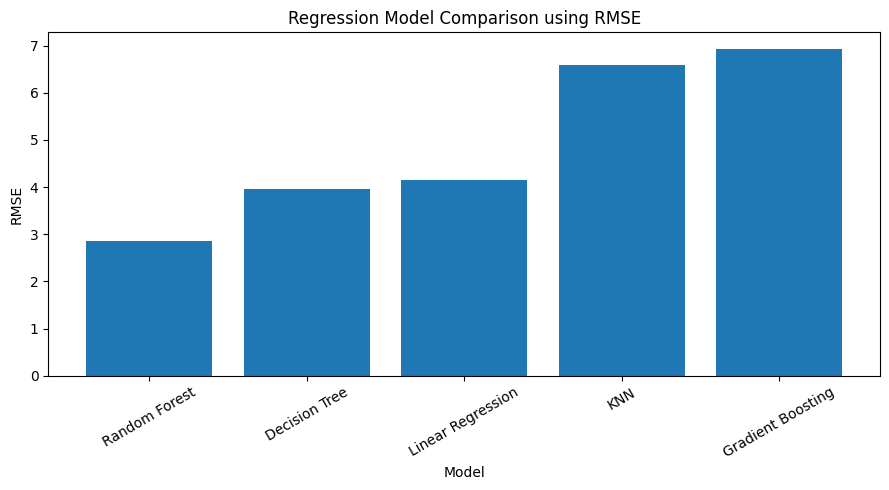

In [17]:
# Visualize RMSE comparison

plt.figure(figsize=(9, 5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Regression Model Comparison using RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import TimeSeriesSplit

In [19]:
# Hyperparameter tuning for Random Forest

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Time-series aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation RMSE:
7.587426861498672


In [20]:
# Evaluate the tuned Random Forest on the unseen test set

best_rf = grid_search.best_estimator_

tuned_predictions = best_rf.predict(X_test)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_predictions)
)

baseline_rmse = results_df.loc[
    results_df["Model"] == "Random Forest", "RMSE"
].iloc[0]

print("Baseline Random Forest RMSE:", round(baseline_rmse, 4))
print("Tuned Random Forest RMSE:", round(tuned_rmse, 4))

if tuned_rmse < baseline_rmse:
    print("\nTuning improved the model.")
else:
    print("\nTuning did not improve the baseline on the test set.")

Baseline Random Forest RMSE: 2.8525
Tuned Random Forest RMSE: 2.7064

Tuning improved the model.


## Final Model Selection

The baseline Random Forest achieved the lowest RMSE among the five initial regression models, with an RMSE of 2.8525.

After hyperparameter tuning using time-series cross-validation, the Random Forest achieved a test RMSE of 2.7064.

Therefore, the tuned Random Forest is selected as the final model for this experiment.

In [21]:
# Select the tuned Random Forest as the final model

final_model = best_rf

print("Final Model: Tuned Random Forest")
print("Final Test RMSE:", round(tuned_rmse, 4))
print("Best Parameters:")
print(grid_search.best_params_)

Final Model: Tuned Random Forest
Final Test RMSE: 2.7064
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


## Actual vs Predicted Tomato Prices

The final model predictions are compared with the actual Tomato prices in the unseen test period.

In [22]:
# Compare actual and predicted Tomato prices

prediction_results = pd.DataFrame({
    "Date": test_dates.values,
    "Actual_Tomato_Price": y_test.values,
    "Predicted_Tomato_Price": tuned_predictions
})

prediction_results["Error"] = (
    prediction_results["Actual_Tomato_Price"]
    - prediction_results["Predicted_Tomato_Price"]
)

display(prediction_results)

,Date,Actual_Tomato_Price,Predicted_Tomato_Price,Error
0,2026-04-09,25.53,27.899234,-2.369234
1,2026-04-16,27.05,26.693951,0.356049
2,2026-04-23,29.37,27.338955,2.031045
3,2026-04-30,31.63,28.262901,3.367099
4,2026-05-07,34.95,31.607834,3.342166
5,2026-05-14,36.32,40.412421,-4.092421
6,2026-05-21,40.05,41.786024,-1.736024
7,2026-05-28,43.58,43.568520,0.011480
8,2026-06-04,43.58,45.245786,-1.665786
9,2026-06-11,45.47,43.862966,1.607034


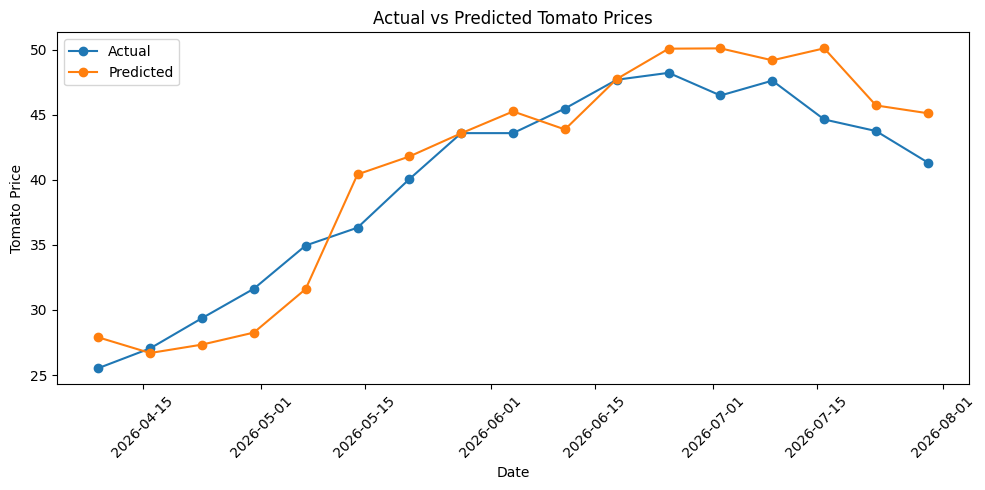

In [23]:
# Plot actual vs predicted prices

plt.figure(figsize=(10, 5))

plt.plot(
    prediction_results["Date"],
    prediction_results["Actual_Tomato_Price"],
    marker="o",
    label="Actual"
)

plt.plot(
    prediction_results["Date"],
    prediction_results["Predicted_Tomato_Price"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Tomato Price")
plt.title("Actual vs Predicted Tomato Prices")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
import joblib

# Save the final trained model

model_filename = "best_model.pkl"

joblib.dump(final_model, model_filename)

print(f"Final model saved as: {model_filename}")

Final model saved as: best_model.pkl


In [25]:
# Verify that the saved model can be loaded

loaded_model = joblib.load(model_filename)

loaded_predictions = loaded_model.predict(X_test)

loaded_rmse = np.sqrt(
    mean_squared_error(y_test, loaded_predictions)
)

print("Loaded model RMSE:", round(loaded_rmse, 4))
print("Original final RMSE:", round(tuned_rmse, 4))

Loaded model RMSE: 2.7064
Original final RMSE: 2.7064


In [26]:
# Install MLflow

!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [27]:
import mlflow
import mlflow.sklearn

print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.2


In [28]:
# Set up MLflow experiment

import mlflow
import mlflow.sklearn

mlflow.set_experiment("Food_Price_Tomato_Forecasting")

print("MLflow experiment created/selected successfully!")

2026/09/03 20:14:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/03 20:14:01 INFO mlflow.store.db.utils: Updating database tables
2026/09/03 20:14:05 INFO mlflow.tracking.fluent: Experiment with name 'Food_Price_Tomato_Forecasting' does not exist. Creating a new experiment.


MLflow experiment created/selected successfully!


In [30]:
# Track baseline models using MLflow

for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        predictions = model.predict(X_test)

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        # Log model name and RMSE
        mlflow.log_param("model", name)
        mlflow.log_metric("rmse", rmse)

        # Log model artifact for supported models
        if name != "KNN":
            mlflow.sklearn.log_model(
                model,
                name="model"
            )
            print(f"{name}: RMSE = {rmse:.4f} | Model logged")

        else:
            print(f"{name}: RMSE = {rmse:.4f} | Metric logged (model artifact skipped)")

print("\nAll baseline model results logged to MLflow.")

Linear Regression: RMSE = 4.1482 | Model logged
Decision Tree: RMSE = 3.9510 | Model logged
Random Forest: RMSE = 2.8525 | Model logged
Gradient Boosting: RMSE = 6.9337 | Model logged
KNN: RMSE = 6.5942 | Metric logged (model artifact skipped)

All baseline model results logged to MLflow.


In [31]:
# Log the tuned Random Forest to MLflow

with mlflow.start_run(run_name="Tuned Random Forest"):

    # Log hyperparameters
    for param_name, param_value in grid_search.best_params_.items():
        mlflow.log_param(param_name, param_value)

    # Log performance metrics
    mlflow.log_metric("baseline_rmse", baseline_rmse)
    mlflow.log_metric("tuned_rmse", tuned_rmse)

    # Log improvement
    improvement_percent = (
        (baseline_rmse - tuned_rmse) / baseline_rmse
    ) * 100

    mlflow.log_metric(
        "improvement_percent",
        improvement_percent
    )

    # Log final model
    mlflow.sklearn.log_model(
        best_rf,
        name="model"
    )

    print("Tuned Random Forest logged successfully!")
    print("Baseline RMSE:", round(baseline_rmse, 4))
    print("Tuned RMSE:", round(tuned_rmse, 4))
    print("Improvement:", round(improvement_percent, 2), "%")

Tuned Random Forest logged successfully!
Baseline RMSE: 2.8525
Tuned RMSE: 2.7064
Improvement: 5.12 %


## MLflow Experiment Tracking

MLflow is used to track the machine learning experiments, including model names, evaluation metrics, hyperparameters, and model artifacts.

In [32]:
# Display MLflow experiment runs

experiment = mlflow.get_experiment_by_name(
    "Food_Price_Tomato_Forecasting"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# Display important columns
mlflow_results = runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.rmse",
        "metrics.baseline_rmse",
        "metrics.tuned_rmse",
        "metrics.improvement_percent"
    ]
].copy()

mlflow_results.columns = [
    "Run ID",
    "Run Name",
    "RMSE",
    "Baseline RMSE",
    "Tuned RMSE",
    "Improvement (%)"
]

display(mlflow_results)

,Run ID,Run Name,RMSE,Baseline RMSE,Tuned RMSE,Improvement (%)
0,c0c9ba6ee9fc41b2b699a152d0e66f9a,Tuned Random Forest,NaN,2.852526,2.706388,5.123129
1,22a84e52cf0741bf8ab43a6ad7e269cb,KNN,6.594162,NaN,NaN,NaN
2,ad77ee73669d424d908501d0ca3ffd52,Gradient Boosting,6.933669,NaN,NaN,NaN
3,7190ffd998744f339ab5fe0f72043dca,Random Forest,2.852526,NaN,NaN,NaN
4,190ac6e7575b4ccbb9cae741e4115b24,Decision Tree,3.951030,NaN,NaN,NaN
5,1598f9fd5c1345caa9b38d829e089584,Linear Regression,4.148229,NaN,NaN,NaN
6,ef191c10bec44cb18e06c9868d74bba6,KNN,6.594162,NaN,NaN,NaN
7,e7483e942ba34176a9db7306c846079e,Gradient Boosting,6.933669,NaN,NaN,NaN
8,27cf01fb18444d16aa5e647534f4c292,Random Forest,2.852526,NaN,NaN,NaN
9,0760af1116e14c018e5b8987d60d5920,Decision Tree,3.951030,NaN,NaN,NaN


In [33]:
# Identify the tuned Random Forest run

tuned_run = runs[
    runs["tags.mlflow.runName"] == "Tuned Random Forest"
].sort_values("start_time").iloc[-1]

print("Final MLflow Run")
print("=" * 40)
print("Run Name:", tuned_run["tags.mlflow.runName"])
print("Baseline RMSE:", tuned_run["metrics.baseline_rmse"])
print("Tuned RMSE:", tuned_run["metrics.tuned_rmse"])
print("Improvement (%):", tuned_run["metrics.improvement_percent"])
print("\nRun ID:")
print(tuned_run["run_id"])

Final MLflow Run
Run Name: Tuned Random Forest
Baseline RMSE: 2.8525261434333262
Tuned RMSE: 2.706387542692532
Improvement (%): 5.123129233266215

Run ID:
c0c9ba6ee9fc41b2b699a152d0e66f9a


## Experiment 4 – Final Results

- Dataset: Maharashtra food-price dataset
- Target variable: Tomato retail price
- Problem type: Regression
- Usable observations: 82
- Training observations: 65
- Testing observations: 17
- Train-test split: Chronological 80:20
- Number of baseline models: 5
- Best baseline model: Random Forest
- Baseline Random Forest RMSE: 2.8525
- Tuned Random Forest RMSE: 2.7064
- Improvement after tuning: 5.12%
- Final model: Tuned Random Forest
- MLflow: Used for experiment tracking
- Model artifact: best_model.pkl